## Importando Bibliotecas

In [ ]:
import yfinance as yf
from datetime import date

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

import joblib

from copy import deepcopy as dc

https://finance.yahoo.com/quote/ETH-USD/

https://www.geeksforgeeks.org/data-analysis/time-series-forecasting-using-pytorch/

## Baixando os Dados

In [ ]:
ticker = 'ETH-USD'
start_date = '2016-01-01'
end_date = date.today().strftime("%Y-%m-%d")

df = yf.download(ticker, start=start_date, end=end_date)

/tmp/ipykernel_1259/3185256320.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [ ]:
end_date

'2026-05-03'

## Analisando os Dados

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3097 entries, 2017-11-09 to 2026-05-02
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, ETH-USD)   3097 non-null   float64
 1   (High, ETH-USD)    3097 non-null   float64
 2   (Low, ETH-USD)     3097 non-null   float64
 3   (Open, ETH-USD)    3097 non-null   float64
 4   (Volume, ETH-USD)  3097 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 145.2 KB


In [ ]:
df = df.drop(['Open', 'High', 'Low'], axis=1)
df.head()

Price,Close,Volume
Ticker,ETH-USD,ETH-USD
Date,,
2017-11-09,320.884003,893249984
2017-11-10,299.252991,885985984
2017-11-11,314.681000,842300992
2017-11-12,307.907990,1613479936
2017-11-13,316.716003,1041889984


In [ ]:
# Normalização
scaler = MinMaxScaler(feature_range=(-1, 1))

X_scaled = scaler.fit_transform(df)
X_scaled

array([[-0.90032707, -0.99440833],
       [-0.90944054, -0.99455793],
       [-0.90294049, -0.99545759],
       ...,
       [-0.08492755, -0.75930028],
       [-0.0685626 , -0.74005741],
       [-0.05965676, -0.87060104]])

In [ ]:
# Scaler que será usado para reverter o dado para a escala original
scaler_clone = MinMaxScaler(feature_range=(-1, 1))
scaler_clone.fit(df[['Close']])

MinMaxScaler(feature_range=(-1, 1))

In [ ]:
df_scaled = pd.DataFrame(
    index=df.index,
    data=X_scaled,
    columns=df.columns
)
df_scaled.head()

Price,Close,Volume
Ticker,ETH-USD,ETH-USD
Date,,
2017-11-09,-0.900327,-0.994408
2017-11-10,-0.909441,-0.994558
2017-11-11,-0.902940,-0.995458
2017-11-12,-0.905794,-0.979576
2017-11-13,-0.902083,-0.991347


In [ ]:
# Adicionando o preço e volume de dias anteriores
def prepare_dataframe(df, steps):
    df = dc(df)

    for i in range(steps, 0, -1):
        df[f'Close(t-{i})'] = df['Close'].shift(i)
        df[f'Volume(t-{i})'] = df['Volume'].shift(i)

    df.dropna(inplace=True)

    return df

In [ ]:
shift = 30

shifted_df = prepare_dataframe(df_scaled, shift)
shifted_df.head()

Price,Close,Volume,Close(t-30),Volume(t-30),Close(t-29),Volume(t-29),Close(t-28),Volume(t-28),Close(t-27),Volume(t-27),...,Close(t-5),Volume(t-5),Close(t-4),Volume(t-4),Close(t-3),Volume(t-3),Close(t-2),Volume(t-2),Close(t-1),Volume(t-1)
Ticker,ETH-USD,ETH-USD,,,,,,,,,...,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,
2017-12-09,-0.836027,-0.971536,-0.900327,-0.994408,-0.909441,-0.994558,-0.902940,-0.995458,-0.905794,-0.979576,...,-0.837416,-0.992096,-0.840333,-0.987747,-0.854950,-0.971652,-0.852498,-0.968947,-0.843388,-0.964688
2017-12-10,-0.849417,-0.983886,-0.909441,-0.994558,-0.902940,-0.995458,-0.905794,-0.979576,-0.902083,-0.991347,...,-0.840333,-0.987747,-0.854950,-0.971652,-0.852498,-0.968947,-0.843388,-0.964688,-0.836027,-0.971536
2017-12-11,-0.818486,-0.976323,-0.902940,-0.995458,-0.905794,-0.979576,-0.902083,-0.991347,-0.893271,-0.990775,...,-0.854950,-0.971652,-0.852498,-0.968947,-0.843388,-0.964688,-0.836027,-0.971536,-0.849417,-0.983886
2017-12-12,-0.761063,-0.906130,-0.905794,-0.979576,-0.902083,-0.991347,-0.893271,-0.990775,-0.895072,-0.997921,...,-0.852498,-0.968947,-0.843388,-0.964688,-0.836027,-0.971536,-0.849417,-0.983886,-0.818486,-0.976323
2017-12-13,-0.739434,-0.919625,-0.902083,-0.991347,-0.893271,-0.990775,-0.895072,-0.997921,-0.896097,-0.996385,...,-0.843388,-0.964688,-0.836027,-0.971536,-0.849417,-0.983886,-0.818486,-0.976323,-0.761063,-0.906130


In [ ]:
# Transformar em array e separar em input e target
y = shifted_df['Close'].to_numpy()
X = np.stack((shifted_df.iloc[:, 2:2+shift].to_numpy(),
              shifted_df.iloc[:, 2+shift:].to_numpy()), axis=2)

split_index_1, split_index_2 = int(X.shape[0] * 0.8), int(X.shape[0] * 0.9)

X_train = X[:split_index_1]
X_test = X[split_index_1 : split_index_2]
X_val = X[split_index_2:]

y_train = y[:split_index_1]
y_test = y[split_index_1 : split_index_2]
y_val = y[split_index_2:]

# Preparar dados para previsão de multi-step direto
num_forecast_steps = 10

def prepare_multistep_data(X, y, forecast_steps):
    """Prepare data for direct multi-step forecasting"""
    X_multistep = []
    y_multistep = []

    for i in range(len(X) - forecast_steps):
        X_multistep.append(X[i])
        # Target: next forecast_steps values
        y_multistep.append(y[i+1:i+1+forecast_steps])

    return np.array(X_multistep), np.array(y_multistep)

X_train_ms, y_train_ms = prepare_multistep_data(X_train, y_train, num_forecast_steps)
X_test_ms, y_test_ms = prepare_multistep_data(X_test, y_test, num_forecast_steps)
X_val_ms, y_val_ms = prepare_multistep_data(X_val, y_val, num_forecast_steps)

X_train_ms.shape, y_train_ms.shape, X_test_ms.shape, y_test_ms.shape, X_val_ms.shape, y_val_ms.shape

((2443, 30, 2),
 (2443, 10, 1),
 (297, 30, 2),
 (297, 10, 1),
 (297, 30, 2),
 (297, 10, 1))

In [ ]:
# Numpy para tensor - Multi-step data
X_train_ms = torch.tensor(X_train_ms, dtype=torch.float32)
X_test_ms = torch.tensor(X_test_ms, dtype=torch.float32)
X_val_ms = torch.tensor(X_val_ms, dtype=torch.float32)
y_train_ms = torch.tensor(y_train_ms, dtype=torch.float32)
y_test_ms = torch.tensor(y_test_ms, dtype=torch.float32)
y_val_ms = torch.tensor(y_val_ms, dtype=torch.float32)

In [ ]:
# Criando um Dataset
class LSTMDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Datasets para modelo multi-step
train_dataset_ms = LSTMDataset(X_train_ms, y_train_ms)
test_dataset_ms = LSTMDataset(X_test_ms, y_test_ms)

In [ ]:
# Dataloaders para modelo multi-step
batch_size = 32
train_loader_ms = DataLoader(train_dataset_ms, batch_size=batch_size, shuffle=True)
test_loader_ms = DataLoader(test_dataset_ms, batch_size=batch_size, shuffle=False)

In [ ]:
# LSTM - Direct multi-step forecasting model
class LSTMMultiStep(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_forecast_steps):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, num_forecast_steps)

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [ ]:
# Multi-step direct forecasting model
model_multistep = LSTMMultiStep(input_size=2, hidden_size=32, num_layers=2, num_forecast_steps=num_forecast_steps)
criterion_multistep = nn.MSELoss()
optimizer_multistep = optim.Adam(model_multistep.parameters(), lr=0.001)

In [ ]:
# Train Multi-Step Model
print('\n=== Training Multi-Step Direct Forecasting Model ===')
EPOCHS_MS = 60
train_hist_ms = []
test_hist_ms = []

for epoch in range(EPOCHS_MS):
    model_multistep.train()
    train_loss = 0.0
    for batch, (X, y) in enumerate(train_loader_ms):
        y_pred = model_multistep(X)
        # Squeeze a última dimensão de y para bater com o shape de y_pred
        loss = criterion_multistep(y_pred, y.squeeze(-1))

        optimizer_multistep.zero_grad()
        loss.backward()
        optimizer_multistep.step()

        train_loss += loss.item()
    average_loss = train_loss / len(train_loader_ms)
    train_hist_ms.append(average_loss)

    model_multistep.eval()
    with torch.no_grad():
        test_loss = 0.0
        for batch, (X, y) in enumerate(test_loader_ms):
            y_pred = model_multistep(X)
            # Squeeze a última dimensão de y para bater com o shape de y_pred
            loss = criterion_multistep(y_pred, y.squeeze(-1))
            test_loss += loss.item()

        average_test_loss = test_loss / len(test_loader_ms)
        test_hist_ms.append(average_test_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS_MS}], Train Loss: {average_loss:.4f}, Test Loss: {average_test_loss:.4f}')


=== Training Multi-Step Direct Forecasting Model ===
Epoch [10/60], Train Loss: 0.0185, Test Loss: 0.0219
Epoch [20/60], Train Loss: 0.0129, Test Loss: 0.0261
Epoch [30/60], Train Loss: 0.0111, Test Loss: 0.0242
Epoch [40/60], Train Loss: 0.0073, Test Loss: 0.0187
Epoch [50/60], Train Loss: 0.0064, Test Loss: 0.0194
Epoch [60/60], Train Loss: 0.0056, Test Loss: 0.0211


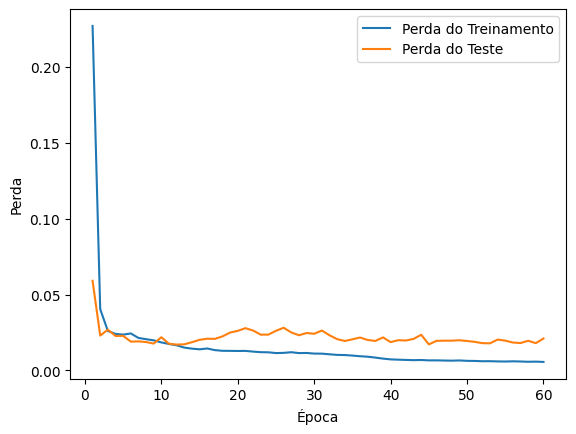

In [ ]:
# Plotar
x = np.linspace(1, EPOCHS_MS, EPOCHS_MS)
plt.plot(x, train_hist_ms, scalex=True, label='Perda do Treinamento')
plt.plot(x, test_hist_ms, scalex=True, label='Perda do Teste')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.show()

In [ ]:
# Função para testar nos dados de validação
def test_on_val(model, X, y):
    model.eval()

    with torch.inference_mode():
        y_pred = model(X)
        y, y_pred = y.numpy(), y_pred.numpy()

        # Mudar y e y_pred para arrays 2D (N, 1) antes de inverse_transform
        y_reshaped = y.reshape(-1, 1)
        y_pred_reshaped = y_pred.reshape(-1, 1)

        y = scaler_clone.inverse_transform(y_reshaped).squeeze()
        y_pred = scaler_clone.inverse_transform(y_pred_reshaped).squeeze()

        error = (y_pred - y) / y

        fig, axs = plt.subplots(2, 1, figsize=(10, 15))

        axs[0].plot(y, label='Close Real')
        axs[0].plot(y_pred, label='Close Previsto')
        axs[0].set_title('Predição')
        axs[0].set_xlabel('Dias')
        axs[0].set_ylabel('Preço')
        axs[0].legend()

        axs[1].hist(error * 100, bins=20, color='blue', alpha=0.7)
        axs[1].set_title('Distribuição do Erro')
        axs[1].set_xlabel('Erro (%)')
        axs[1].set_ylabel('Frequência')
        axs[1].grid(True)
        plt.show()

        print(f'\nErro Relativo (%) min: {(error.min() * 100):.2f} %')
        print(f'Erro Relativo (%) max: {(error.max() * 100):.2f} %')
        print(f'Erro Relativo (%) mean: {(error.mean() * 100):.2f} %')
        print(f'Erro Relativo (%) std: {(error.std() * 100):.2f} %')


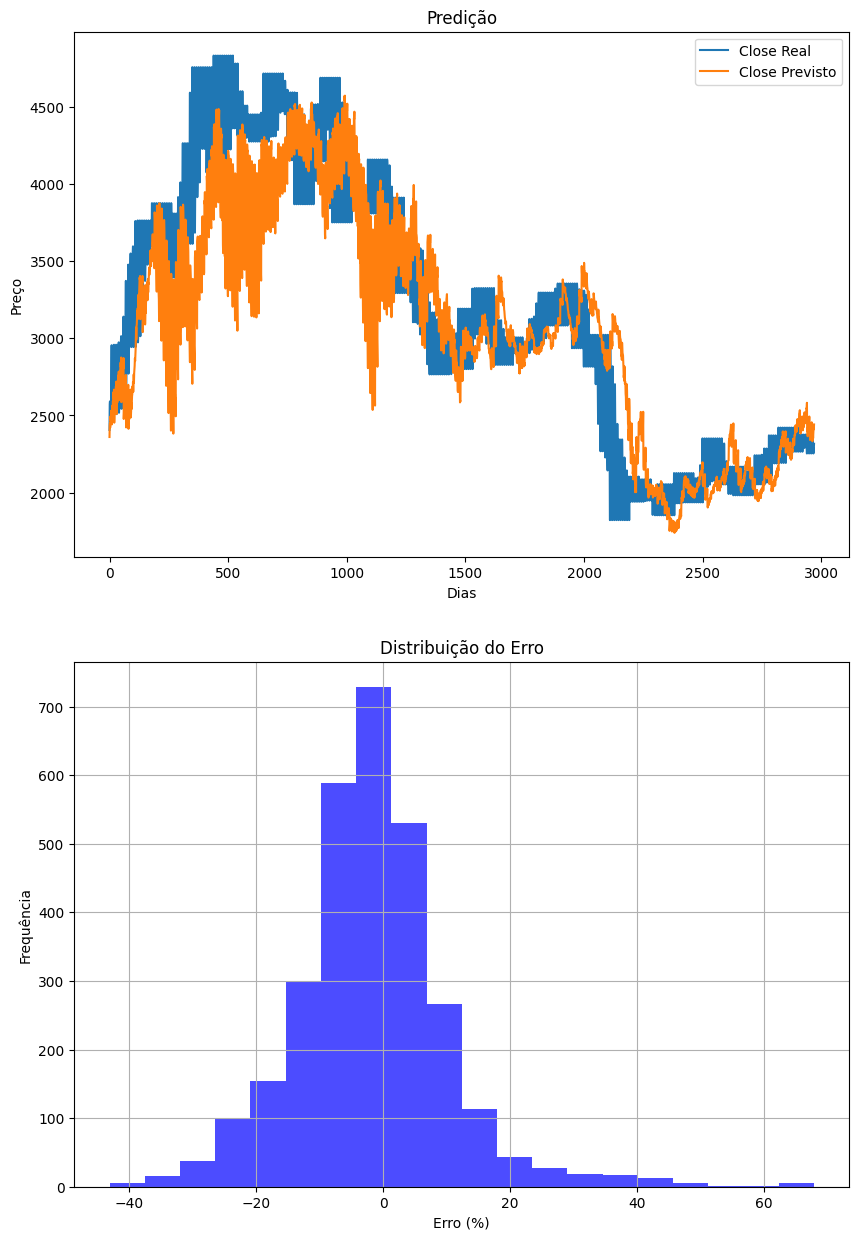


Erro Relativo (%) min: -43.13 %
Erro Relativo (%) max: 67.94 %
Erro Relativo (%) mean: -1.82 %
Erro Relativo (%) std: 12.06 %


In [ ]:
test_on_val(model_multistep, X_val_ms, y_val_ms)

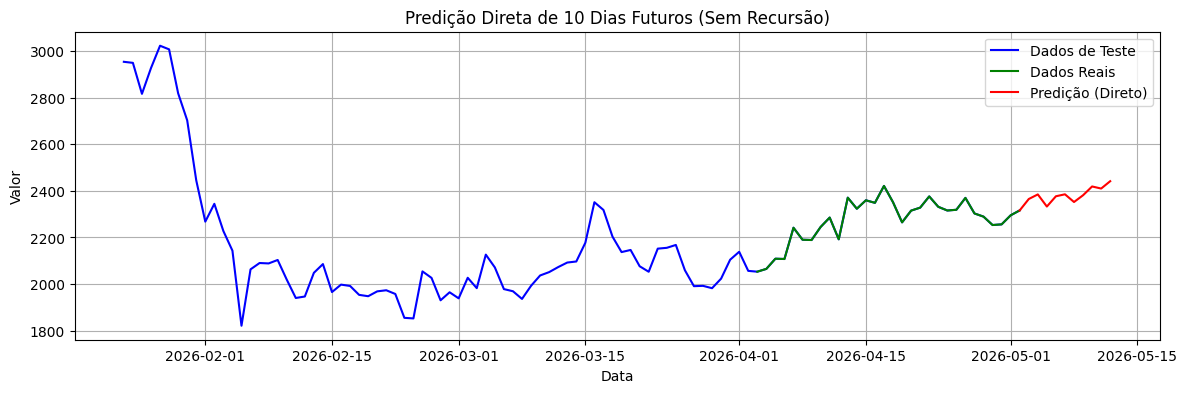


=== Multi-Step Model Validation Metrics ===
Erro Relativo (%) min: -43.13 %
Erro Relativo (%) max: 67.94 %
Erro Relativo (%) mean: -1.82 %
Erro Relativo (%) std: 12.06 %


In [ ]:
# Previsão Direta Multi-step
sequence_to_forecast = X_val_ms[-1:].to('cpu')  # Last validation sequence

with torch.no_grad():
    forecasted_values = model_multistep(sequence_to_forecast).cpu().numpy()[0]

# Predição de transformação inversa
forecast_vals_inv = scaler_clone.inverse_transform(np.array(forecasted_values).reshape(-1, 1)).flatten()

# Preparação para plotar
val_data_start_index = split_index_2
val_data_for_plot_start_date = shifted_df.index[val_data_start_index]
val_data = df.loc[val_data_for_plot_start_date:]

last_date = val_data.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(1), periods=num_forecast_steps)

# Pegar o último valor real e combinar com predições
actual_last_val = val_data['Close'][-1:].values.flatten()
combined_preds = np.concatenate([actual_last_val, forecast_vals_inv])

# Criar datas no x-axis
all_dates = val_data.index[-1:].append(future_dates)

plt.rcParams['figure.figsize'] = [14, 4]
plt.plot(val_data.index[-100:], val_data['Close'][-100:], label="Dados de Teste", color="b")
plt.plot(val_data.index[-30:], val_data['Close'][-30:], label='Dados Reais', color='green')
plt.plot(all_dates, combined_preds, label='Predição (Direto)', color='red')

plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.title('Predição Direta de 10 Dias Futuros (Sem Recursão)')
plt.grid(True)
plt.show()

# Avaliar o modelo multi-step nos dados de validação
model_multistep.eval()
with torch.no_grad():
    val_predictions_ms = model_multistep(X_val_ms).cpu().numpy()

# Calcular médias para todos os 10 futuros passos
all_errors = []
for step in range(num_forecast_steps):
    step_predictions = val_predictions_ms[:, step]
    step_targets = y_val_ms.cpu().numpy()[:, step]

    # Inverse transform
    step_pred_inv = scaler_clone.inverse_transform(step_predictions.reshape(-1, 1)).flatten()
    step_target_inv = scaler_clone.inverse_transform(step_targets.reshape(-1, 1)).flatten()

    # Calcular erro relativo
    step_error = (step_pred_inv - step_target_inv) / step_target_inv
    all_errors.extend(step_error)

all_errors = np.array(all_errors)

print(f'\n=== Multi-Step Model Validation Metrics ===')
print(f'Erro Relativo (%) min: {(all_errors.min() * 100):.2f} %')
print(f'Erro Relativo (%) max: {(all_errors.max() * 100):.2f} %')
print(f'Erro Relativo (%) mean: {(all_errors.mean() * 100):.2f} %')
print(f'Erro Relativo (%) std: {(all_errors.std() * 100):.2f} %')

In [ ]:
val_data.tail()

Price,Close,Volume
Ticker,ETH-USD,ETH-USD
Date,,
2026-04-28,2289.419678,12761522276
2026-04-29,2253.415771,21884731493
2026-04-30,2256.251221,12309496389
2026-05-01,2295.093750,13243880777
2026-05-02,2316.231934,6905015549


In [ ]:
# Salvando o Modelo
torch.save(model_multistep.state_dict(), 'model.pth')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(scaler_clone, 'inverse_scaler.pkl')

['inverse_scaler.pkl']

In [ ]:
def predict_future_from_history(
    data_referencia,
    dias_previsao,
    dias_anteriores,
    scaler,
    scaler_clone,
    model,
    num_forecast_steps,
    ticker='ETH-USD'
):
    """
    Preve o preco futuro com base em dados historicos fornecidos pelo usuario
    usando um modelo LSTM multi-step de forma recursiva.

    Args:
        data_referencia (str ou datetime): Data a partir da qual as previsões começarão.
        dias_previsao (int): Número de dias futuros a serem previstos.
        dias_anteriores (int): Número de dias históricos para usar como input para a previsão (sequence_length).
        scaler (MinMaxScaler): Scaler original usado para normalizar Close e Volume.
        scaler_clone (MinMaxScaler): Scaler usado especificamente para reverter o preço 'Close'.
        model (nn.Module): O modelo LSTM treinado.
        num_forecast_steps (int): O número de passos que o modelo prediz em uma única chamada.
        ticker (str): O ticker do ativo a ser previsto.

    Returns:
        pandas.DataFrame: DataFrame contendo os preços históricos e previstos.
    """

    data_referencia = pd.to_datetime(data_referencia).normalize()
    dias_previsao = int(dias_previsao)
    dias_anteriores = int(dias_anteriores)

    if dias_previsao <= 0:
        raise ValueError("dias_previsao deve ser maior que zero.")

    if dias_anteriores <= 0:
        raise ValueError("dias_anteriores deve ser maior que zero.")

    # INTERVALO DE DADOS HISTÓRICOS
    # Ajustar para garantir que temos dias_anteriores + 1 dia para a referência
    data_inicial = data_referencia - pd.Timedelta(days=dias_anteriores)

    # =========================
    # BAIXAR DADOS HISTÓRICOS
    # =========================
    historical_df = yf.download(
        ticker,
        start=data_inicial.strftime('%Y-%m-%d'),
        end=(data_referencia + timedelta(days=1)).strftime('%Y-%m-%d'), # Inclui o dia da referência
        progress=False
    )

    if historical_df.empty:
        raise ValueError("Nenhum dado histórico encontrado para o período especificado.")

    # Keep only Close price and Volume
    historical_prices = historical_df[['Close', 'Volume']].copy()
    historical_prices.rename(columns={'Close': 'Historical_Close', 'Volume': 'Historical_Volume'}, inplace=True)
    historical_prices.index = historical_prices.index.tz_localize(None)

    # =====================================
    # PREPARAR ENTRADA PARA LSTM
    # =====================================
    historical_values = historical_prices[['Historical_Close', 'Historical_Volume']].values
    scaled_historical_input = scaler.transform(historical_values)

    # Garantir que a sequência de entrada tenha o comprimento correto
    if len(scaled_historical_input) < dias_anteriores:
        pad_size = dias_anteriores - len(scaled_historical_input)
        # Repetir a última linha (Close, Volume) pad_size vezes para preencher
        padded_input = np.tile(scaled_historical_input[-1], (pad_size, 1))
        current_sequence_input = np.concatenate(
            (scaled_historical_input, padded_input),
            axis=0
        )[-dias_anteriores:]
    else:
        current_sequence_input = scaled_historical_input[-dias_anteriores:].copy()

    # =========================
    # PREDIÇÕES (Recursivo Multi-Step)
    # =========================
    forecasted_values_scaled_close = []
    model.eval()

    steps_predicted_so_far = 0
    last_known_volume_scaled = current_sequence_input[-1, 1] # Assumir o último volume conhecido para os inputs futuros

    with torch.no_grad():
        while steps_predicted_so_far < dias_previsao:
            # Preparar o tensor de input para o modelo
            input_tensor = torch.tensor(
                current_sequence_input,
                dtype=torch.float32
            ).view(1, dias_anteriores, 2)

            # Obter a previsão multi-step do modelo
            batch_predictions_scaled_close = model(input_tensor).numpy()[0] # shape (num_forecast_steps,)

            # Determinar quantos passos de previsão pegar deste batch
            take_n = min(num_forecast_steps, dias_previsao - steps_predicted_so_far)

            # Adicionar as previsões ao resultado
            forecasted_values_scaled_close.extend(batch_predictions_scaled_close[:take_n])

            # Atualizar current_sequence_input para a próxima rodada de previsão (se houver)
            if steps_predicted_so_far + take_n < dias_previsao:
                # Criar o segmento de "Close" e "Volume" a partir das previsões e do volume assumido
                predicted_closes_to_add_to_input = batch_predictions_scaled_close[:take_n].reshape(-1, 1)
                volume_column_for_predicted = np.full((take_n, 1), last_known_volume_scaled)
                predicted_segment_scaled = np.concatenate((predicted_closes_to_add_to_input, volume_column_for_predicted), axis=1)

                # Deslocar a sequência e concatenar as novas previsões
                current_sequence_input = np.concatenate(
                    (current_sequence_input[take_n:], predicted_segment_scaled),
                    axis=0
                )

            steps_predicted_so_far += take_n

    # Reverter as previsões para a escala original usando scaler_clone
    predicted_prices = scaler_clone.inverse_transform(
        np.array(forecasted_values_scaled_close).reshape(-1, 1)
    ).flatten()

    # Gerar as datas futuras para as previsões
    future_dates = pd.date_range(
        start=data_referencia + timedelta(days=1),
        periods=dias_previsao,
        freq='D'
    )

    prediction_df = pd.DataFrame(
        {
            'Predicted_Close': predicted_prices
        },
        index=future_dates
    )

    # =========================
    # COMBINAR RESULTADOS
    # =========================
    all_dates = historical_prices.index.union(future_dates).sort_values()
    result_df = pd.DataFrame(index=all_dates, columns=['Historical_Close', 'Predicted_Close'])
    result_df['Historical_Close'] = historical_prices['Historical_Close']
    result_df.loc[prediction_df.index, 'Predicted_Close'] = prediction_df['Predicted_Close']

    return result_df